# Messages per Newsgroup

Visualization of message counts per newsgroup channel.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("../data/messages_per_group.csv")
df["channel"] = df["channel"].str.replace(".mbox", "", regex=False)
df = df[df.channel != "Total"]
df = df.sort_values("message_count", ascending=False)
df.head(10)

,channel,message_count
322,no.alt.frustrasjoner,273279
16,no.sport.fotball,180577
46,no.teknologi.bil,178192
301,no.alt.motorsykler,177968
31,no.general,168759
157,no.samfunn.religion,168287
224,no.samfunn.politikk.diverse,166472
220,no.it.os.mac.diverse,166426
318,no.it.os.unix.linux.diverse,121643
277,no.alt.diskusjoner,119961


In [3]:
print(f"Total groups: {len(df)}")
print(f"Total messages: {df['message_count'].sum():,}")

Total groups: 331
Total messages: 5,985,471


# Top 20 newsgroups
Number of messages in top 20 vs rest of groups

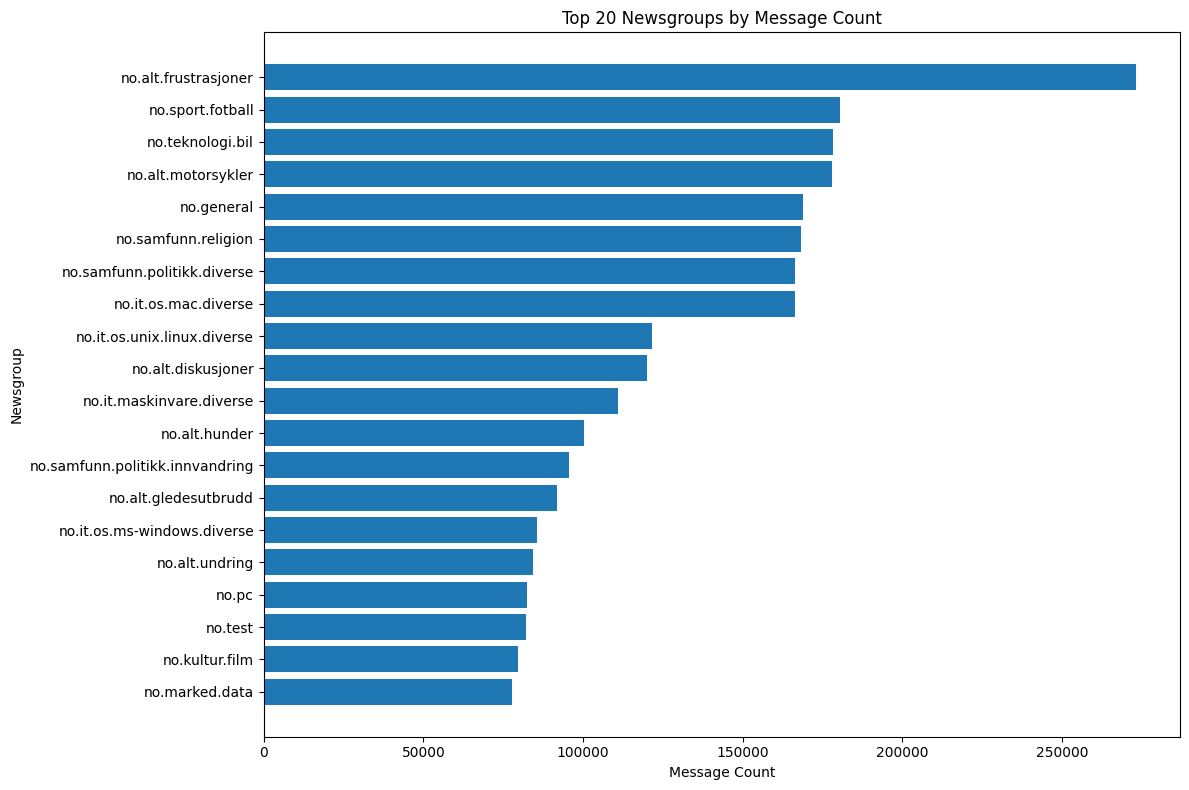

In [4]:
top_20 = df.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_20["channel"], top_20["message_count"])
ax.set_xlabel("Message Count")
ax.set_ylabel("Newsgroup")
ax.set_title("Top 20 Newsgroups by Message Count")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

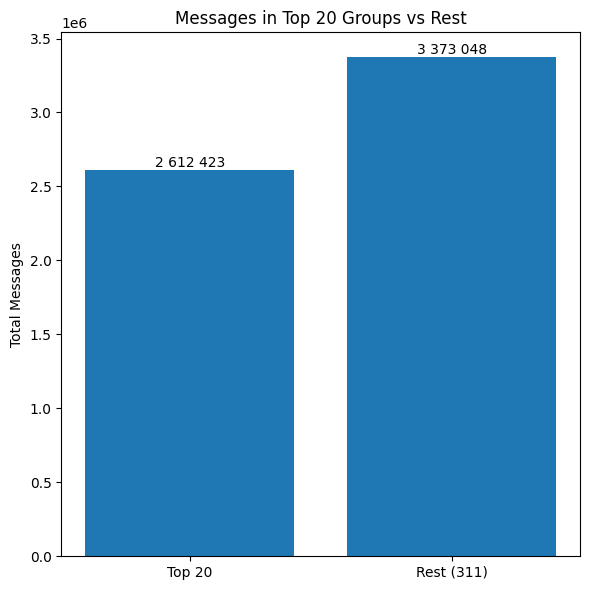

In [5]:
top_20_sum = df.head(20)["message_count"].sum()
rest_sum = df.iloc[20:]["message_count"].sum()

fig, ax = plt.subplots(figsize=(6, 6))
ax.bar(["Top 20", "Rest (311)"], [top_20_sum, rest_sum])
for i, v in enumerate([top_20_sum, rest_sum]):
    ax.text(i, v, f"{v:,}".replace(",", " "), ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Total Messages")
ax.set_title("Messages in Top 20 Groups vs Rest")
plt.tight_layout()
plt.show()

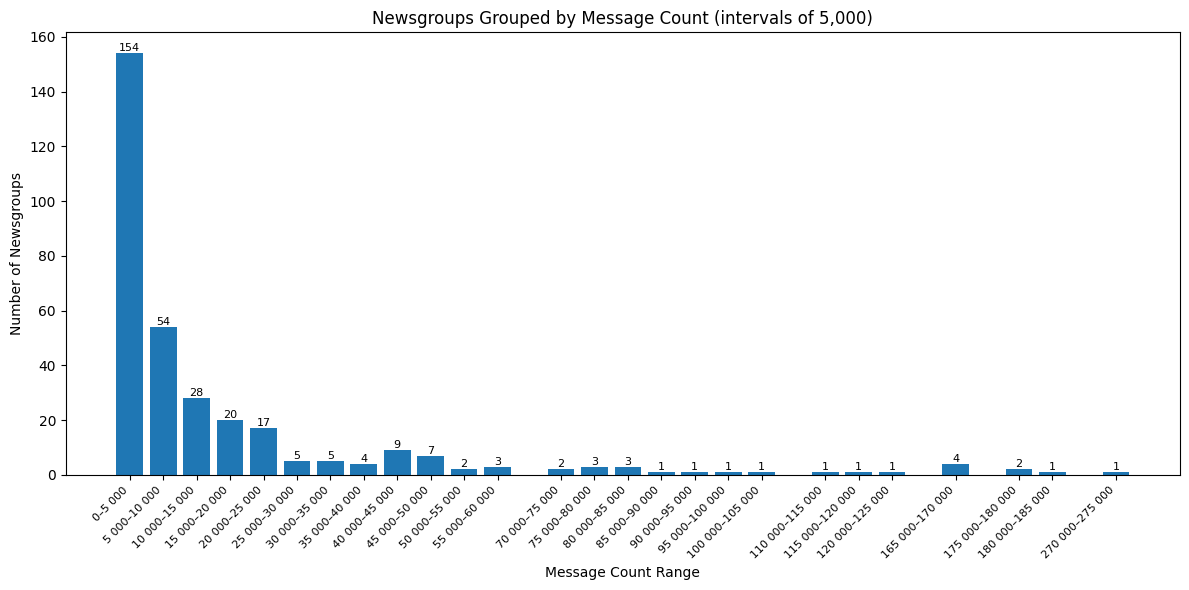

In [6]:
# Distribution of newsgroups by message count (bins of 5000)
bin_size = 5000
max_count = int(np.ceil(df["message_count"].max() / bin_size) * bin_size)
bins = np.arange(0, max_count + bin_size, bin_size)

counts, bin_edges = np.histogram(df["message_count"], bins=bins)

# Get indices of non-empty bins
non_empty = np.where(counts > 0)[0]
labels = [
    f"{int(bin_edges[i]):,}–{int(bin_edges[i + 1]):,}".replace(",", " ")
    for i in non_empty
]
counts = counts[non_empty]

# Build x positions with gaps where intervals are missing
gap_width = 0.9
x_positions = [0.0]
for i in range(1, len(non_empty)):
    step = 1.0
    if non_empty[i] - non_empty[i - 1] > 1:
        step += gap_width
    x_positions.append(x_positions[-1] + step)

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x_positions, counts, width=0.8)
ax.set_xticks(x_positions)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
for x, c in zip(x_positions, counts):
    ax.text(x, c, str(c), ha="center", va="bottom", fontsize=8)
ax.set_xlabel("Message Count Range")
ax.set_ylabel("Number of Newsgroups")
ax.set_title("Newsgroups Grouped by Message Count (intervals of 5,000)")
plt.tight_layout()
plt.show()